In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:


df = pd.read_csv("Mall_Customers.csv.csv")


df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:


df.shape

(200, 5)

In [ ]:


df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:


df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:


df.duplicated().sum()

np.int64(0)

In [ ]:


df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000



The dataset contains 200 customer records and 5 columns.
 The dataset contains no missing values.
The dataset contains no duplicate records.
CustomerID is a unique identifier and will not be used as a clustering feature.
Gender is a categorical feature that can be analyzed during EDA.
Age, Annual Income, and Spending Score are numerical features.
Annual Income and Spending Score will be considered important features for customer segmentation.

Exploratory Data Analysis (EDA)

In [ ]:


df['Gender'].value_counts()

,count
Gender,
Female,112
Male,88


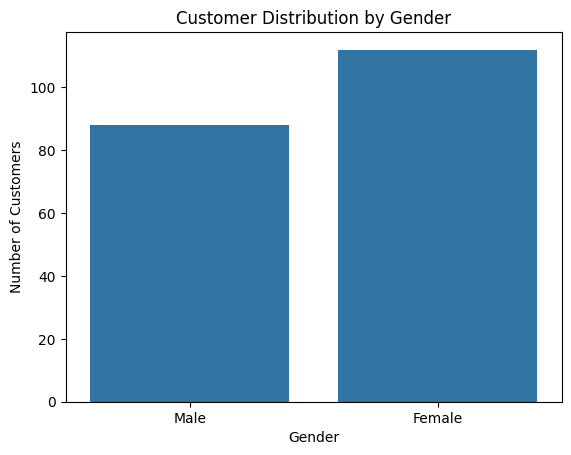

In [ ]:


sns.countplot(data=df, x='Gender')

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

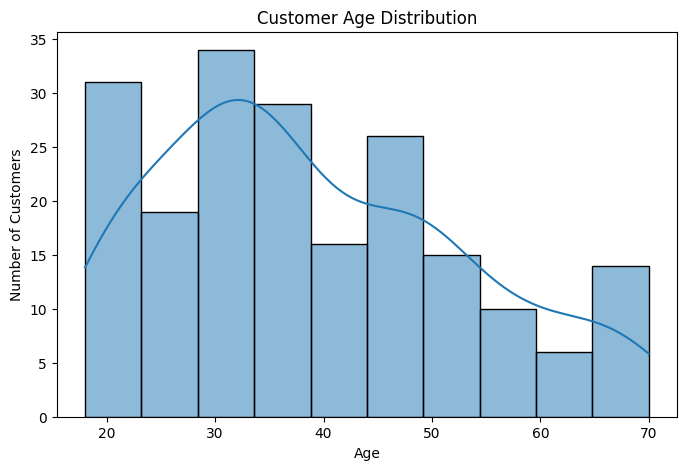

In [ ]:


plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Age', bins=10, kde=True)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

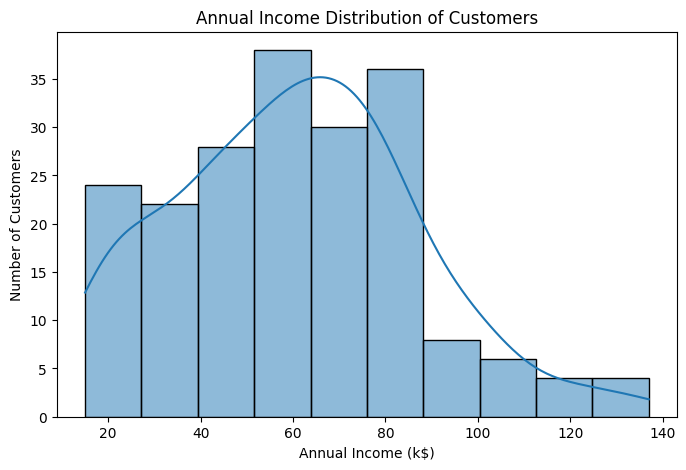

In [ ]:


plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Annual Income (k$)', bins=10, kde=True)

plt.title('Annual Income Distribution of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

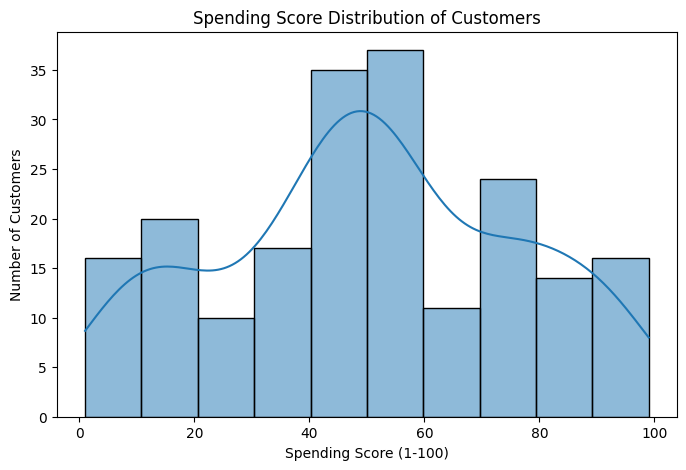

In [ ]:


plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Spending Score (1-100)', bins=10, kde=True)

plt.title('Spending Score Distribution of Customers')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Number of Customers')

plt.show()

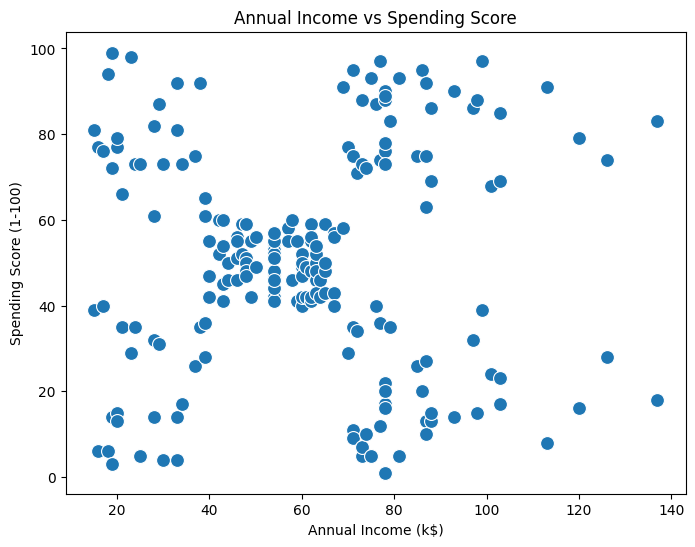

In [ ]:

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    s=100
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

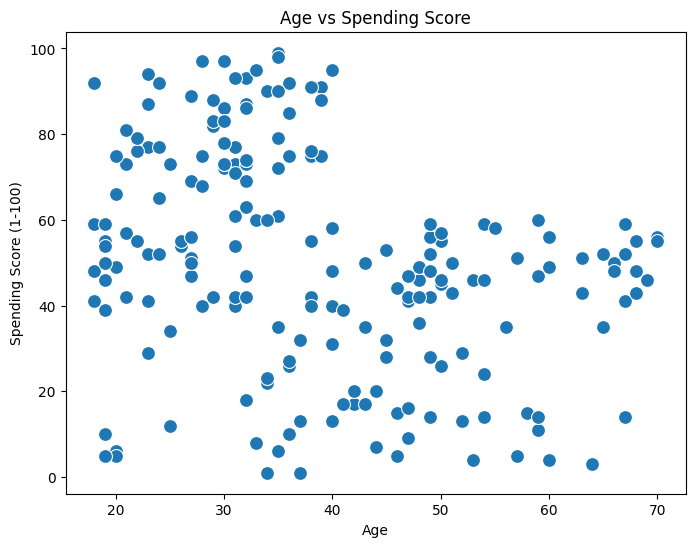

In [ ]:


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Spending Score (1-100)',
    s=100
)

plt.title('Age vs Spending Score')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')

plt.show()

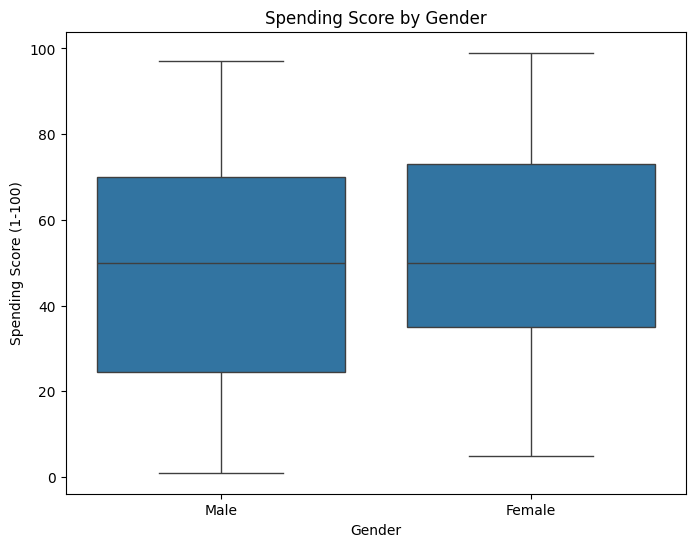

In [ ]:


plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)'
)

plt.title('Spending Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Spending Score (1-100)')

plt.show()

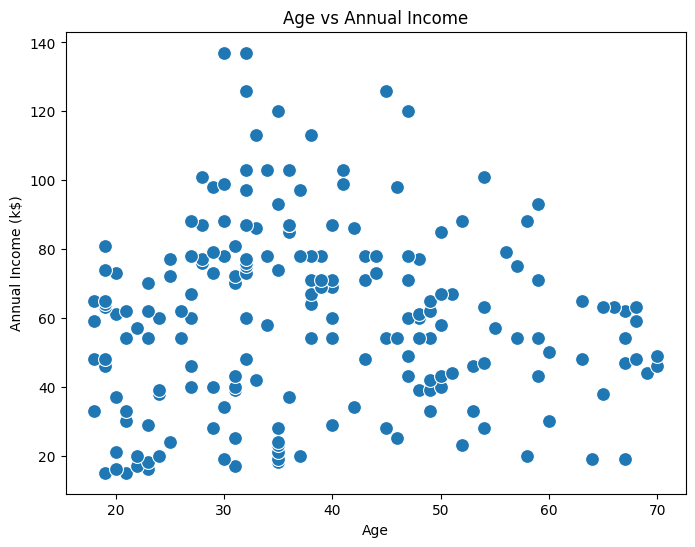

In [ ]:


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)',
    s=100
)

plt.title('Age vs Annual Income')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')

plt.show()

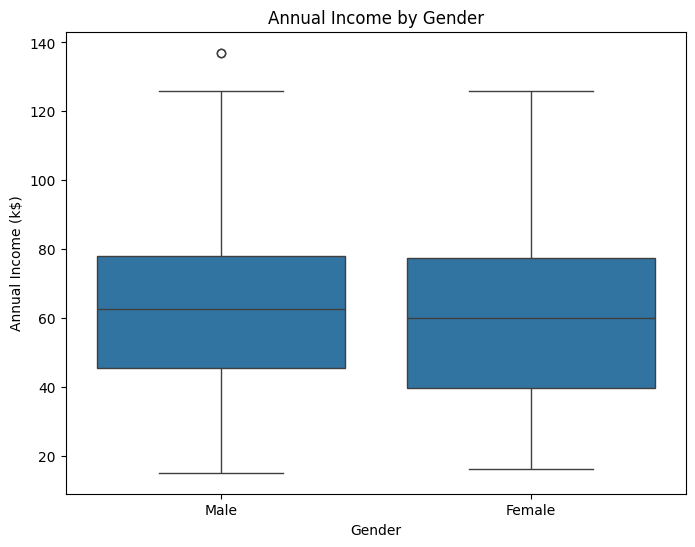

In [ ]:


plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x='Gender',
    y='Annual Income (k$)'
)

plt.title('Annual Income by Gender')
plt.xlabel('Gender')
plt.ylabel('Annual Income (k$)')

plt.show()

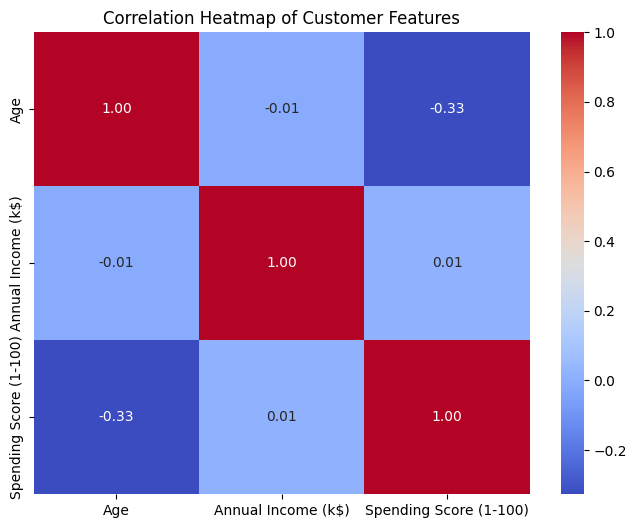

In [ ]:


correlation = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Customer Features')

plt.show()

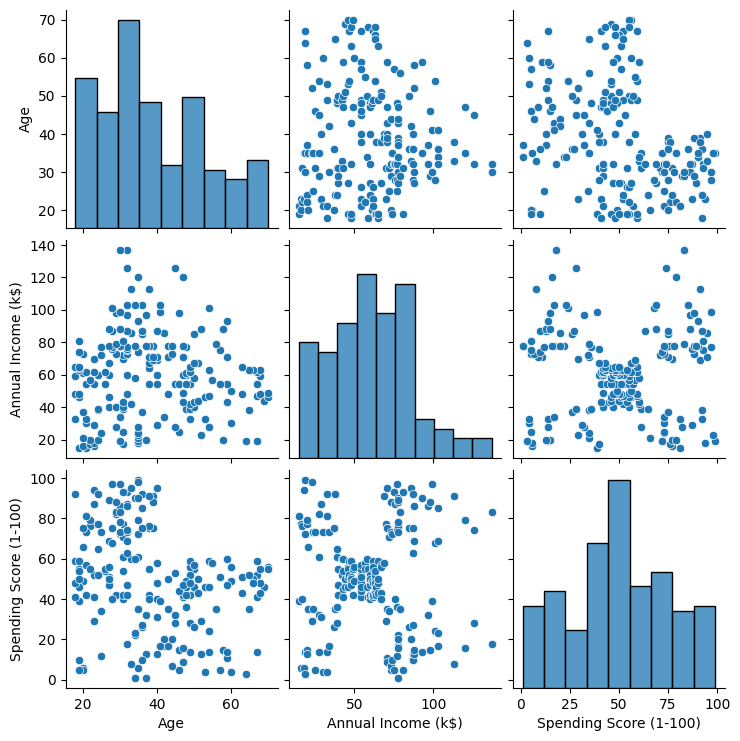

In [ ]:


sns.pairplot(
    df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
)

plt.show()

EDA Summary and Observations

The dataset contains customers with different demographic, income, and spending characteristics.
 The gender distribution provides an overview of the male and female customer population.
 The age distribution shows the range and concentration of customer ages.
 Annual income varies across customers, indicating differences in purchasing capacity.
 Spending Score shows variation in customer spending behavior.
The Annual Income vs Spending Score visualization provides an initial indication that customers may form distinct groups based on income and spending behavior.
Age and Spending Score were explored to understand possible differences in spending behavior across age groups.
Gender was analyzed in relation to Spending Score and Annual Income for demographic comparison.
 The correlation heatmap and pairplot provide an overall view of relationships among the numerical customer attributes.
 Annual Income and Spending Score appear particularly relevant for the primary customer segmentation analysis.

Feature Selection

In [ ]:


X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:


X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [ ]:


X.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [ ]:


from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)


X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

In [ ]:

from sklearn.cluster import KMeans


wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss

[399.99999999999994,
 269.69101219276405,
 157.70400815035939,
 108.92131661364358,
 65.56840815571681,
 55.057348270385965,
 44.86475569922555,
 37.22818767758587,
 32.39226763033118,
 29.981897788243703]

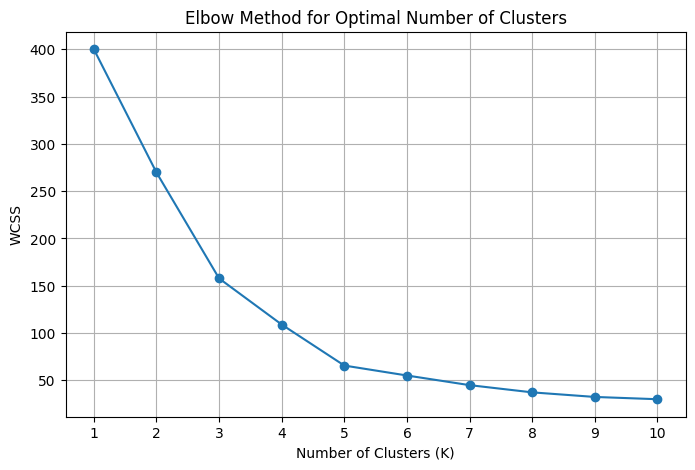

In [ ]:


plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.xticks(range(1, 11))
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score


silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

silhouette_scores

[np.float64(0.3212707813918878),
 np.float64(0.46658474419000145),
 np.float64(0.4939069237513199),
 np.float64(0.5546571631111091),
 np.float64(0.5398800926790663),
 np.float64(0.5281492781108291),
 np.float64(0.4552147906587443),
 np.float64(0.4570853966942764),
 np.float64(0.4431713026508046)]

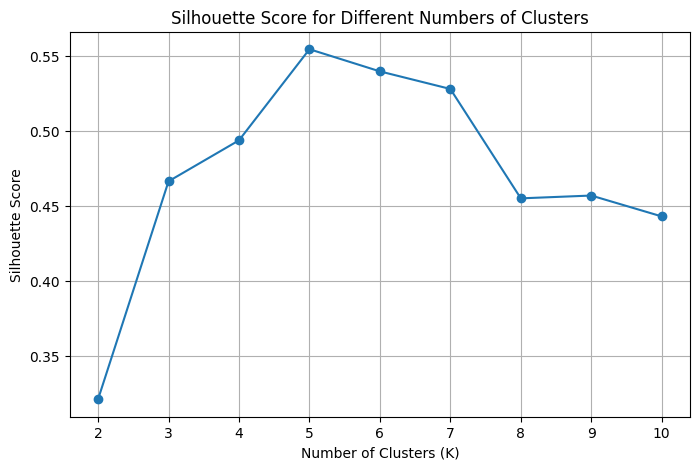

In [ ]:


plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:


results = pd.DataFrame({
    'K': range(2, 11),
    'WCSS': wcss[1:],
    'Silhouette Score': silhouette_scores
})

results

,K,WCSS,Silhouette Score
0,2,269.691012,0.321271
1,3,157.704008,0.466585
2,4,108.921317,0.493907
3,5,65.568408,0.554657
4,6,55.057348,0.539880
5,7,44.864756,0.528149
6,8,37.228188,0.455215
7,9,32.392268,0.457085
8,10,29.981898,0.443171


In [ ]:


best_k = results.loc[
    results['Silhouette Score'].idxmax(), 'K'
]

best_k

np.int64(5)

In [ ]:
best_k

np.int64(5)

In [ ]:


best_silhouette = results['Silhouette Score'].max()

results[results['Silhouette Score'] == best_silhouette]

,K,WCSS,Silhouette Score
3,5,65.568408,0.554657


In [ ]:


optimal_k = int(best_k)

print("Optimal number of clusters:", optimal_k)

Optimal number of clusters: 5


In [ ]:


kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)


cluster_labels = kmeans.fit_predict(X_scaled)


cluster_labels[:10]

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2], dtype=int32)

In [ ]:


df['Cluster'] = cluster_labels


df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [37]:


df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,81
1,39
2,22
3,35
4,23


In [38]:


cluster_profile = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(2)

cluster_profile

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


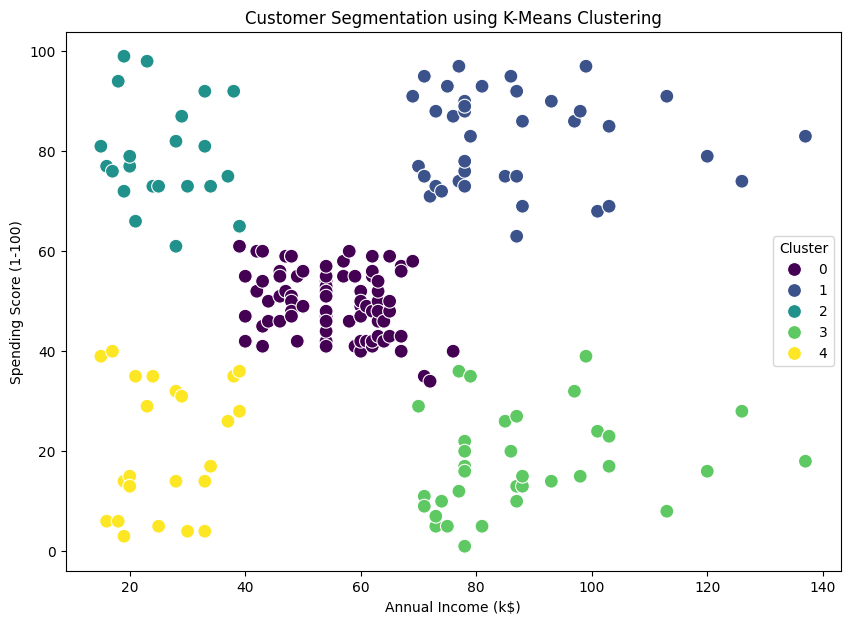

In [39]:


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='viridis',
    s=100
)

plt.title('Customer Segmentation using K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.show()

In [40]:


cluster_profile = df.groupby('Cluster').agg(
    Customer_Count=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending_Score=('Spending Score (1-100)', 'mean')
).round(2)

cluster_profile

,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
Cluster,,,,
0,81,42.72,55.30,49.52
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
3,35,41.11,88.20,17.11
4,23,45.22,26.30,20.91


In [41]:


cluster_profile.sort_values(
    by='Average_Spending_Score',
    ascending=False
)

,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
Cluster,,,,
1,39,32.69,86.54,82.13
2,22,25.27,25.73,79.36
0,81,42.72,55.30,49.52
4,23,45.22,26.30,20.91
3,35,41.11,88.20,17.11


In [42]:


income_profile = cluster_profile[
    ['Customer_Count', 'Average_Income']
].sort_values(
    by='Average_Income',
    ascending=False
)

income_profile

,Customer_Count,Average_Income
Cluster,,
3,35,88.20
1,39,86.54
0,81,55.30
4,23,26.30
2,22,25.73


In [43]:


spending_profile = cluster_profile[
    ['Customer_Count', 'Average_Spending_Score']
].sort_values(
    by='Average_Spending_Score',
    ascending=False
)

spending_profile

,Customer_Count,Average_Spending_Score
Cluster,,
1,39,82.13
2,22,79.36
0,81,49.52
4,23,20.91
3,35,17.11


In [44]:


business_profile = cluster_profile[
    ['Customer_Count', 'Average_Income', 'Average_Spending_Score']
].sort_values(
    by=['Average_Income', 'Average_Spending_Score'],
    ascending=[False, False]
)

business_profile

,Customer_Count,Average_Income,Average_Spending_Score
Cluster,,,
3,35,88.20,17.11
1,39,86.54,82.13
0,81,55.30,49.52
4,23,26.30,20.91
2,22,25.73,79.36


In [45]:


cluster_labels_map = {}

for cluster in cluster_profile.index:
    income = cluster_profile.loc[cluster, 'Average_Income']
    spending = cluster_profile.loc[cluster, 'Average_Spending_Score']

    if income >= cluster_profile['Average_Income'].median() and spending >= cluster_profile['Average_Spending_Score'].median():
        label = 'High-Value Customers'
    elif income >= cluster_profile['Average_Income'].median() and spending < cluster_profile['Average_Spending_Score'].median():
        label = 'High-Income Low-Spending Customers'
    elif income < cluster_profile['Average_Income'].median() and spending >= cluster_profile['Average_Spending_Score'].median():
        label = 'Low-Income High-Spending Customers'
    else:
        label = 'Low-Value Customers'

    cluster_labels_map[cluster] = label

cluster_labels_map

{0: 'High-Value Customers',
 1: 'High-Value Customers',
 2: 'Low-Income High-Spending Customers',
 3: 'High-Income Low-Spending Customers',
 4: 'Low-Value Customers'}

In [46]:


df['Segment'] = df['Cluster'].map(cluster_labels_map)


df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Low-Value Customers
1,2,Male,21,15,81,2,Low-Income High-Spending Customers
2,3,Female,20,16,6,4,Low-Value Customers
3,4,Female,23,16,77,2,Low-Income High-Spending Customers
4,5,Female,31,17,40,4,Low-Value Customers
5,6,Female,22,17,76,2,Low-Income High-Spending Customers
6,7,Female,35,18,6,4,Low-Value Customers
7,8,Female,23,18,94,2,Low-Income High-Spending Customers
8,9,Male,64,19,3,4,Low-Value Customers
9,10,Female,30,19,72,2,Low-Income High-Spending Customers


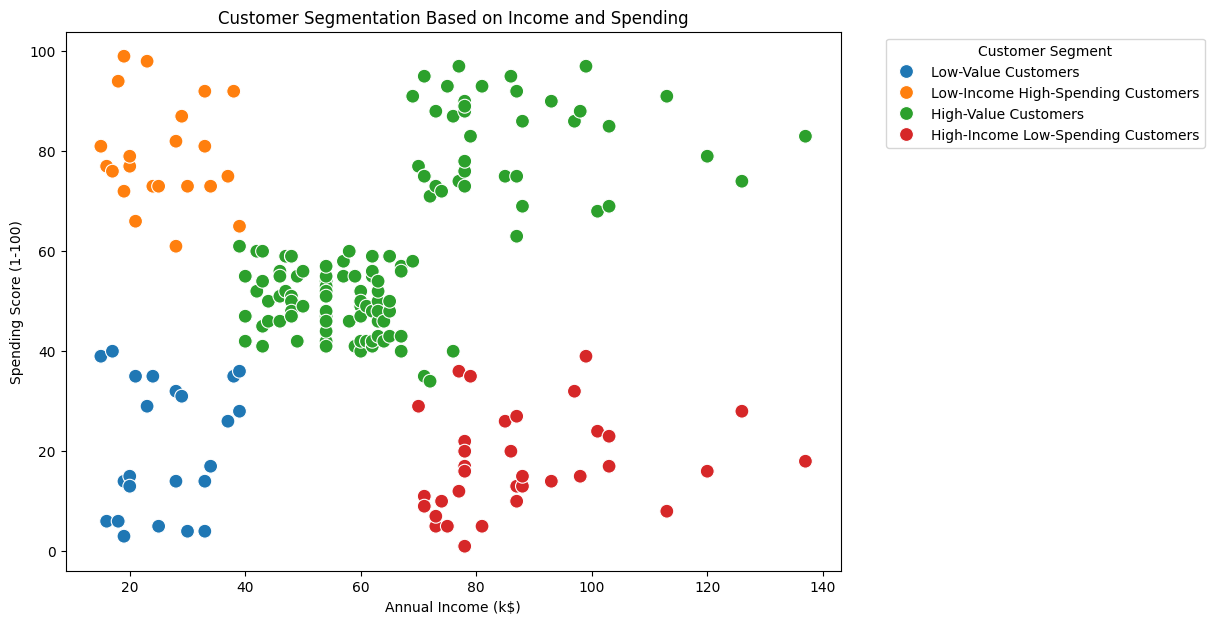

In [47]:


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Segment',
    s=100
)

plt.title('Customer Segmentation Based on Income and Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

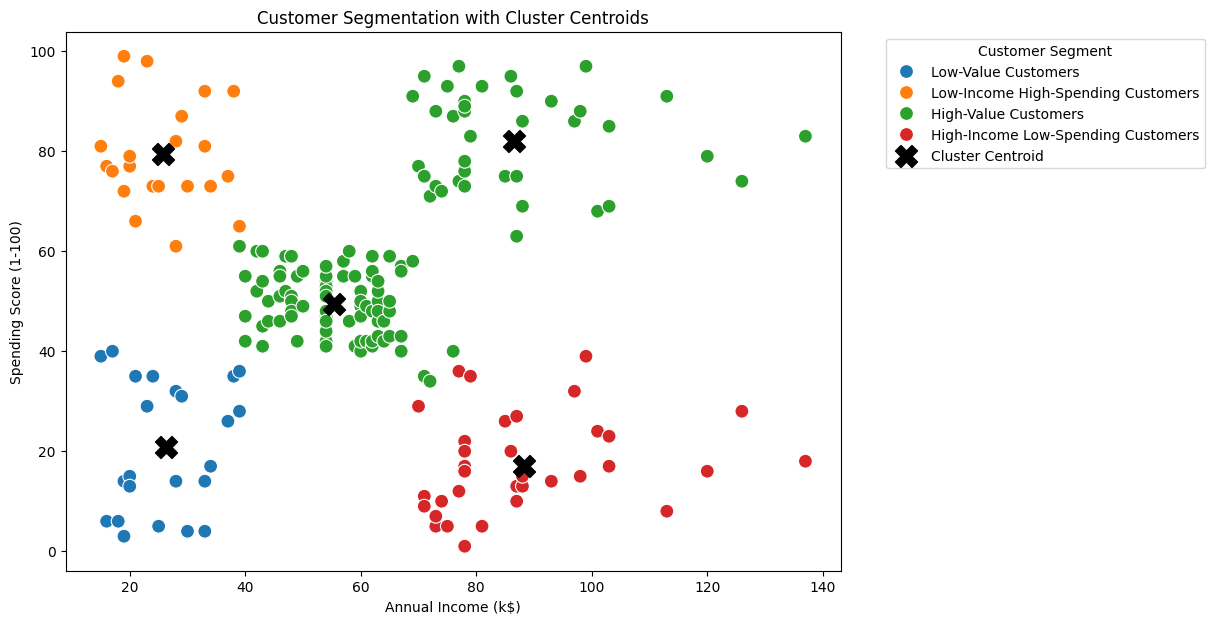

In [48]:


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Segment',
    s=100
)


centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='X',
    s=250,
    color='black',
    label='Cluster Centroid'
)

plt.title('Customer Segmentation with Cluster Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(
    title='Customer Segment',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

In [49]:


segment_counts = df['Segment'].value_counts()

segment_counts

,count
Segment,
High-Value Customers,120
High-Income Low-Spending Customers,35
Low-Value Customers,23
Low-Income High-Spending Customers,22


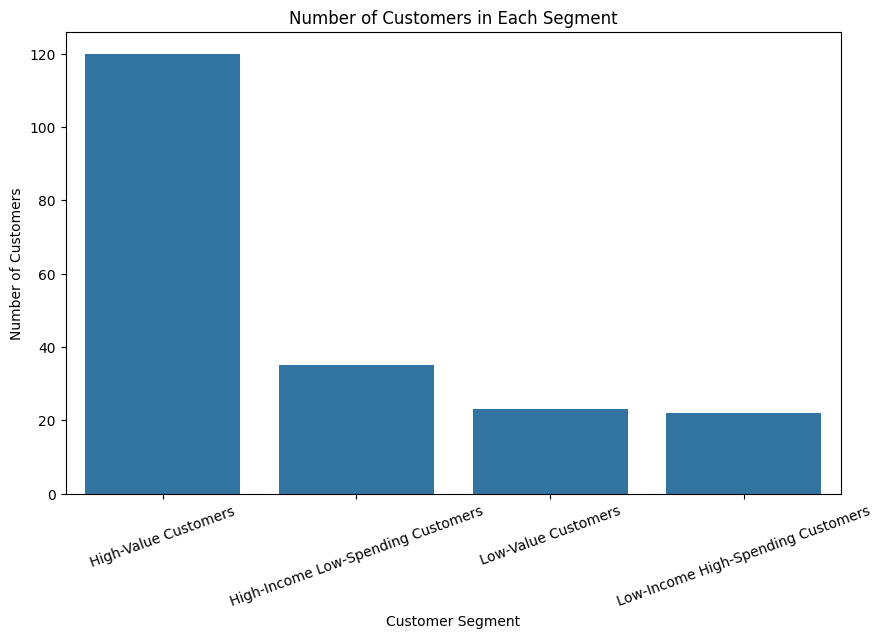

In [50]:


plt.figure(figsize=(10, 6))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)

plt.show()

In [51]:


recommendation_profile = cluster_profile.copy()

recommendation_profile['Segment'] = recommendation_profile.index.map(
    cluster_labels_map
)

recommendation_profile = recommendation_profile[
    [
        'Segment',
        'Customer_Count',
        'Average_Age',
        'Average_Income',
        'Average_Spending_Score'
    ]
]

recommendation_profile

,Segment,Customer_Count,Average_Age,Average_Income,Average_Spending_Score
Cluster,,,,,
0,High-Value Customers,81,42.72,55.30,49.52
1,High-Value Customers,39,32.69,86.54,82.13
2,Low-Income High-Spending Customers,22,25.27,25.73,79.36
3,High-Income Low-Spending Customers,35,41.11,88.20,17.11
4,Low-Value Customers,23,45.22,26.30,20.91


In [52]:


recommendations = {
    'High-Value Customers':
        'Provide premium offers, loyalty rewards, personalized recommendations, and exclusive products.',

    'High-Income Low-Spending Customers':
        'Use personalized promotions, product recommendations, and targeted offers to increase engagement and spending.',

    'Low-Income High-Spending Customers':
        'Encourage repeat purchases through loyalty programs, affordable bundles, and targeted promotional campaigns.',

    'Low-Value Customers':
        'Use cost-effective promotions, discounts, and personalized campaigns to gradually improve engagement and spending.'
}

recommendation_profile['Business_Recommendation'] = (
    recommendation_profile['Segment'].map(recommendations)
)

recommendation_profile

,Segment,Customer_Count,Average_Age,Average_Income,Average_Spending_Score,Business_Recommendation
Cluster,,,,,,
0,High-Value Customers,81,42.72,55.30,49.52,"Provide premium offers, loyalty rewards, perso..."
1,High-Value Customers,39,32.69,86.54,82.13,"Provide premium offers, loyalty rewards, perso..."
2,Low-Income High-Spending Customers,22,25.27,25.73,79.36,Encourage repeat purchases through loyalty pro...
3,High-Income Low-Spending Customers,35,41.11,88.20,17.11,"Use personalized promotions, product recommend..."
4,Low-Value Customers,23,45.22,26.30,20.91,"Use cost-effective promotions, discounts, and ..."


In [53]:


segment_percentage = (
    df['Segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_percentage

,proportion
Segment,
High-Value Customers,60.0
High-Income Low-Spending Customers,17.5
Low-Value Customers,11.5
Low-Income High-Spending Customers,11.0


In [54]:


recommendation_profile['Segment_Percentage'] = (
    recommendation_profile['Segment']
    .map(segment_percentage)
)

recommendation_profile

,Segment,Customer_Count,Average_Age,Average_Income,Average_Spending_Score,Business_Recommendation,Segment_Percentage
Cluster,,,,,,,
0,High-Value Customers,81,42.72,55.30,49.52,"Provide premium offers, loyalty rewards, perso...",60.0
1,High-Value Customers,39,32.69,86.54,82.13,"Provide premium offers, loyalty rewards, perso...",60.0
2,Low-Income High-Spending Customers,22,25.27,25.73,79.36,Encourage repeat purchases through loyalty pro...,11.0
3,High-Income Low-Spending Customers,35,41.11,88.20,17.11,"Use personalized promotions, product recommend...",17.5
4,Low-Value Customers,23,45.22,26.30,20.91,"Use cost-effective promotions, discounts, and ...",11.5


In [55]:


final_business_profile = recommendation_profile[
    [
        'Segment',
        'Customer_Count',
        'Segment_Percentage',
        'Average_Age',
        'Average_Income',
        'Average_Spending_Score',
        'Business_Recommendation'
    ]
].sort_values(
    by='Segment_Percentage',
    ascending=False
)

final_business_profile

,Segment,Customer_Count,Segment_Percentage,Average_Age,Average_Income,Average_Spending_Score,Business_Recommendation
Cluster,,,,,,,
0,High-Value Customers,81,60.0,42.72,55.30,49.52,"Provide premium offers, loyalty rewards, perso..."
1,High-Value Customers,39,60.0,32.69,86.54,82.13,"Provide premium offers, loyalty rewards, perso..."
3,High-Income Low-Spending Customers,35,17.5,41.11,88.20,17.11,"Use personalized promotions, product recommend..."
4,Low-Value Customers,23,11.5,45.22,26.30,20.91,"Use cost-effective promotions, discounts, and ..."
2,Low-Income High-Spending Customers,22,11.0,25.27,25.73,79.36,Encourage repeat purchases through loyalty pro...


In [56]:


final_silhouette_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Final Silhouette Score:", round(final_silhouette_score, 4))

Final Silhouette Score: 0.5547


In [57]:


cluster_size = df['Cluster'].value_counts().sort_index()

cluster_size_percentage = (
    df['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_size_summary = pd.DataFrame({
    'Customer_Count': cluster_size,
    'Percentage': cluster_size_percentage
})

cluster_size_summary

,Customer_Count,Percentage
Cluster,,
0,81,40.5
1,39,19.5
2,22,11.0
3,35,17.5
4,23,11.5


In [58]:


evaluation_summary = pd.DataFrame({
    'Metric': [
        'Optimal Number of Clusters',
        'Final Silhouette Score',
        'Number of Customers',
        'Number of Features'
    ],
    'Value': [
        optimal_k,
        round(final_silhouette_score, 4),
        len(df),
        X.shape[1]
    ]
})

evaluation_summary

,Metric,Value
0,Optimal Number of Clusters,5.0000
1,Final Silhouette Score,0.5547
2,Number of Customers,200.0000
3,Number of Features,2.0000


Final Project Conclusion

The Customer Segmentation project successfully applied an end-to-end unsupervised machine learning workflow to identify meaningful customer groups based on Annual Income and Spending Score.

 Key Findings

The dataset contains 200 customers and 5 original attributes.
Data-quality analysis confirmed that there were no missing values or duplicate records.
Exploratory Data Analysis was performed to understand customer demographics, income, and spending behavior.
Annual Income and Spending Score were selected as the primary features for customer segmentation.
The selected features were standardized using StandardScaler before applying K-Means.
 The Elbow Method and Silhouette Score were used to determine an appropriate number of clusters.
K-Means clustering was then applied to segment customers based on their income and spending behavior.
Each cluster was analyzed using customer count, average age, average income, and average spending score.
Business-friendly segment labels were created based on the characteristics of the identified customer groups.
Segment-specific business recommendations were developed to support targeted marketing and customer engagement strategies.
The final clustering model was evaluated using the Silhouette Score and cluster-size analysis.

Business Value

The segmentation results can help businesses understand different customer groups and develop more targeted strategies for marketing, promotions, customer retention, and personalized offers.

Overall Outcome

The project demonstrates an end-to-end Data Science workflow:

**Data Collection → Data Quality → EDA → Feature Selection → Feature Scaling → Optimal K Selection → K-Means Clustering → Cluster Profiling → Business Segmentation → Recommendations → Model Evaluation**

Documentation / GitHub / Presentation

Customer Segmentation Using K-Means Clustering

 Project Overview

This project develops an unsupervised machine learning solution to segment mall customers based on their Annual Income and Spending Score.

The objective is to identify distinct customer groups and translate the resulting clusters into meaningful business segments that can support targeted marketing, personalized promotions, customer engagement, and retention strategies.

Business Problem

Businesses often have customers with different income levels and spending behaviors. Treating all customers with the same marketing strategy may result in inefficient campaigns and missed opportunities.

This project uses **K-Means Clustering** to identify groups of customers with similar characteristics and provide actionable business recommendations for each segment.

Dataset

Dataset: Mall Customer Segmentation Data

Source:Kaggle

Records: 200 customers

Original Features:
CustomerID
Gender
Age
Annual Income (k$)
Spending Score (1-100)

 Machine Learning Approach

The project follows an end-to-end Data Science workflow:

**Data Loading → Data Quality Analysis → EDA → Feature Selection → Feature Scaling → Elbow Method → Silhouette Score → K-Means Clustering → Cluster Profiling → Business Segmentation → Recommendations → Evaluation**

 Primary Segmentation Features
 Annual Income (k$)
 Spending Score (1-100)

Expected Business Outcome

The resulting customer segments can help businesses design more targeted strategies based on customer income and spending behavior.

 Customer Segmentation Using K-Means Clustering

 Project Overview

This project uses unsupervised machine learning to segment mall customers based on their Annual Income and Spending Score.

The objective is to identify distinct customer groups and develop actionable business strategies for targeted marketing and customer engagement.

---

 Business Problem

Businesses have customers with different income levels and spending behaviors. A single marketing strategy may not be equally effective for every customer.

This project identifies customer segments using K-Means clustering to support data-driven marketing decisions.

---

 Dataset

Dataset: Mall Customer Segmentation Data

Source: Kaggle

Records: 200 customers

 Features

CustomerID
Gender
Age
Annual Income (k$)
Spending Score (1-100)

---

 Technologies Used

Python
Pandas
NumPy
 Matplotlib
Seaborn
Scikit-learn
 Google Colab
K-Means Clustering

---

 Project Workflow

1. Data Loading
2. Data Quality Analysis
3. Exploratory Data Analysis
4. Feature Selection
5. Feature Scaling
6. Elbow Method
7. Silhouette Score
8. K-Means Clustering
9. Cluster Profiling
10. Customer Segment Analysis
11. Business Recommendations
12. Model Evaluation

---

 Machine Learning

Algorithm

K-Means Clustering
 Selected Features

Annual Income (k$)
 Spending Score (1-100)
 Cluster Selection

The optimal number of clusters was evaluated using:

Elbow Method
Silhouette Score

---

 Key Analysis

The project analyzes customer segments based on:

 Customer demographics
Annual income
Spending behavior
Segment size
Cluster characteristics

---

Business Insights

The identified segments can support:

Targeted marketing campaigns
Personalized offers
Customer retention
Cross-selling and upselling
Premium customer strategies

---

 Business Recommendations

Recommendations are developed according to the income and spending characteristics of each customer segment.

---

 Model Evaluation

The clustering model is evaluated using:

WCSS
Silhouette Score
Cluster-size analysis
Cluster visualization
Business interpretability

---

 Project Outcome

The project demonstrates an end-to-end customer segmentation workflow, transforming raw customer data into meaningful customer groups and actionable business insights.

---

 Author

Vadlamuri Sohan Aravind

Data Science | Machine Learning | Business Analytics

Customer Segmentation Using K-Means Clustering

 1. Project Overview

2. Business Problem

3. Dataset Description

 4. Import Libraries

5. Load Dataset

6. Data Understanding & Data Quality

7. Exploratory Data Analysis (EDA)

 8. Feature Selection

 9. Feature Scaling

 10. Determining the Optimal Number of Clusters

 10.1 Elbow Method

 10.2 Silhouette Score

 11. K-Means Clustering

 12. Cluster Profiling

13. Customer Segment Visualization

14. Business Recommendations

 15. Model Evaluation

16. Final Business Insights

17. Project Conclusion

In [59]:


df.to_csv("Customer_Segmentation_Results.csv", index=False)

print("Customer segmentation results saved successfully.")

Customer segmentation results saved successfully.


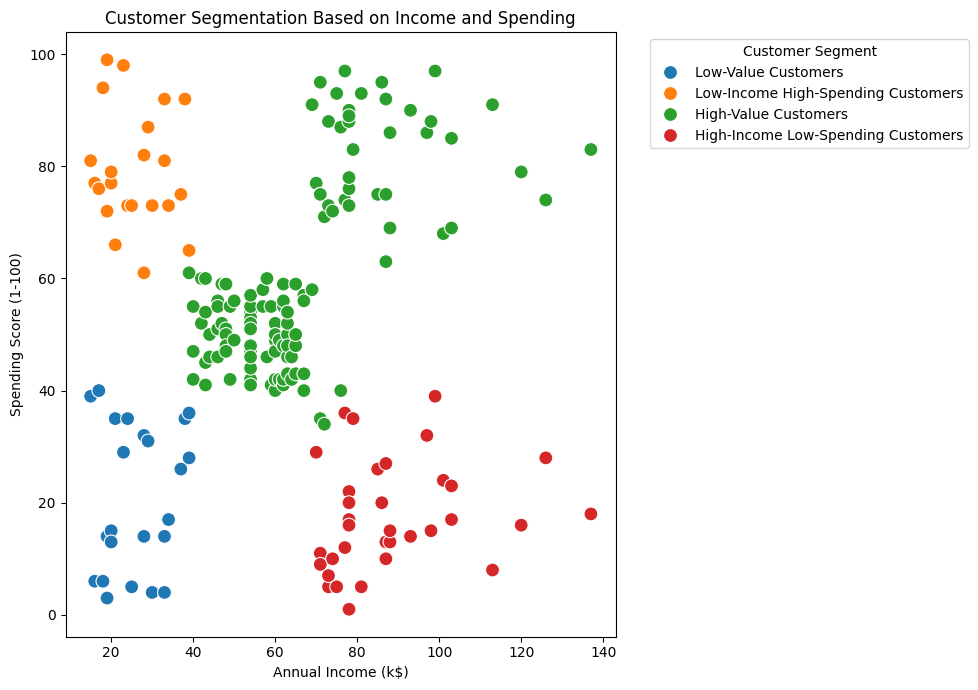

In [60]:


plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Segment',
    s=100
)

plt.title('Customer Segmentation Based on Income and Spending')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(
    title='Customer Segment',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()

plt.savefig(
    'customer_segmentation.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

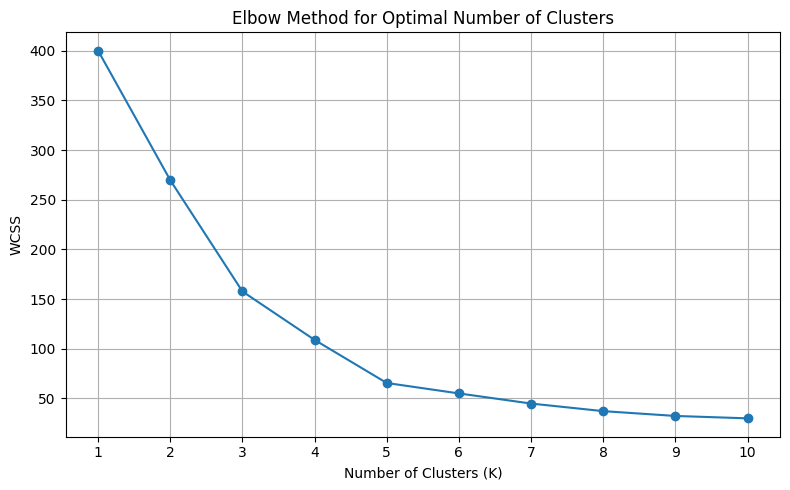

In [61]:


plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.xticks(range(1, 11))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    'elbow_method.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

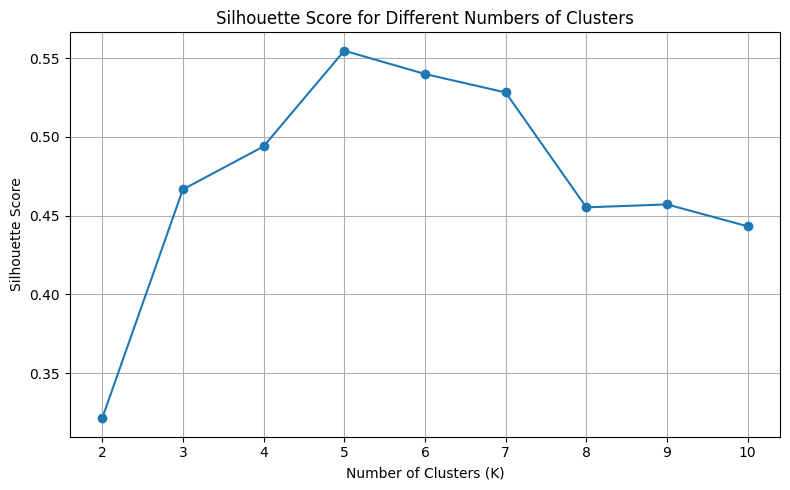

In [62]:


plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.title('Silhouette Score for Different Numbers of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.xticks(range(2, 11))
plt.grid(True)

plt.tight_layout()

plt.savefig(
    'silhouette_score.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

<Figure size 1000x600 with 0 Axes>

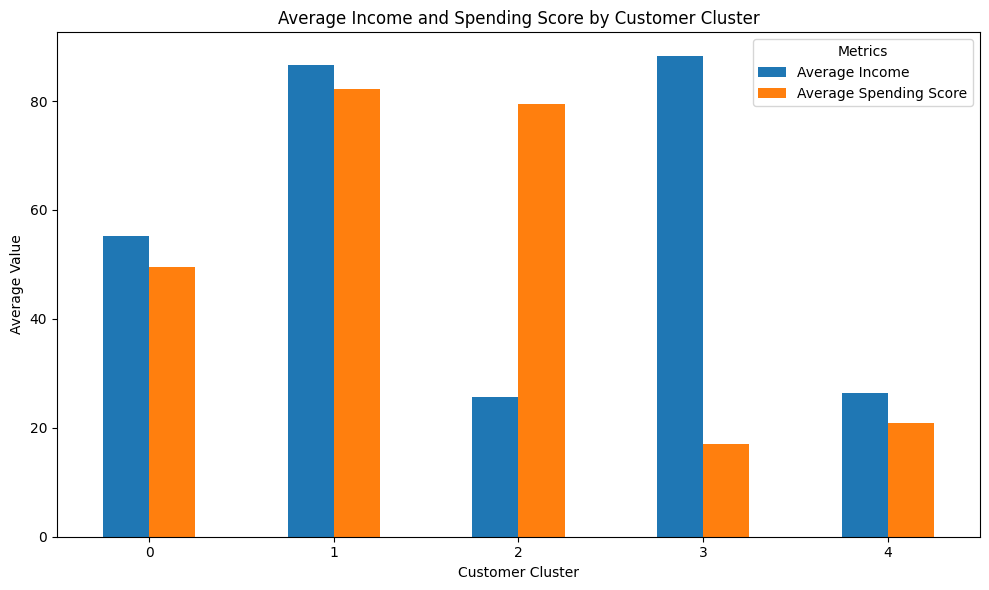

In [63]:


plt.figure(figsize=(10, 6))

cluster_profile[['Average_Income', 'Average_Spending_Score']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Income and Spending Score by Customer Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(
    ['Average Income', 'Average Spending Score'],
    title='Metrics'
)

plt.tight_layout()

plt.savefig(
    'cluster_profile.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

Customer-Segmentation-KMeans/
│
├── README.md
│
├── Customer_Segmentation.ipynb
│
├── data/
│   └── Mall_Customers.csv
│
├── results/
│   └── Customer_Segmentation_Results.csv
│
└── images/
    ├── customer_segmentation.png
    ├── elbow_method.png
    ├── silhouette_score.png
    └── cluster_profile.png